# Customer Sign-Up Behaviour & Data Quality Audit
**Analyst:** Vanshika Karnwal  
**Dataset:** Rapid Scale SaaS - Customer Signups (300 records, Jan-Oct 2024)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

## Project Overview
This notebook analyses customer sign-up data for Rapid Scale, a SaaS company with tiered subscription plans. The analysis covers:
- Data quality audit (missing values, duplicates, inconsistencies)
- User acquisition trends by source, region, and plan
- Marketing opt-in behaviour by demographics
- Support ticket analysis within 2 weeks of sign-up

**Business goal:** Help the Marketing and Onboarding teams optimise campaigns and engagement workflows.

## 1. Setup - Libraries & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_signups.csv")
df

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaN,Instagram,NaN,basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,02-01-24,LinkedIn,West,basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,03-01-24,Google,North,PREMIUM,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,04-01-24,YouTube,NaN,Pro,No,40,Male
4,CUST00004,NaN,matthew4@mailhub.org,05-01-24,LinkedIn,West,Premium,No,25,Other
...,...,...,...,...,...,...,...,...,...,...
295,CUST00295,Gary Smith,gary95@example.com,22-10-24,Google,West,PREMIUM,Yes,40,NaN
296,CUST00296,Anthony Roberts,anthony96@mailhub.org,23-10-24,Google,Central,Basic,Yes,25,Female
297,CUST00297,Timothy Mclaughlin,NaN,24-10-24,Instagram,West,Basic,Yes,60,NaN
298,CUST00298,Justin Mcintyre,justin98@mailhub.org,25-10-24,YouTube,South,Premium,No,53,male


## 2. Data Quality Audit
We begin by inspecting the dataset for missing values, duplicate records, and inconsistent formatting before any analysis.

In [3]:
df.shape

(300, 10)

In [4]:
df.columns

Index(['customer_id', 'name', 'email', 'signup_date', 'source', 'region',
       'plan_selected', 'marketing_opt_in', 'age', 'gender'],
      dtype='object')

In [5]:
df.dtypes

customer_id         object
name                object
email               object
signup_date         object
source              object
region              object
plan_selected       object
marketing_opt_in    object
age                 object
gender              object
dtype: object

In [6]:
df.describe()

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
count,298,291,266,298,291,270,292,290,288,292
unique,298,291,265,295,7,5,8,3,11,7
top,CUST00000,Joshua Bryant,lisa11@mailhub.org,not a date,YouTube,North,Premium,No,40,Other
freq,1,1,2,4,58,65,57,156,50,59


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       298 non-null    object
 1   name              291 non-null    object
 2   email             266 non-null    object
 3   signup_date       298 non-null    object
 4   source            291 non-null    object
 5   region            270 non-null    object
 6   plan_selected     292 non-null    object
 7   marketing_opt_in  290 non-null    object
 8   age               288 non-null    object
 9   gender            292 non-null    object
dtypes: object(10)
memory usage: 23.6+ KB


In [8]:
df.isnull().sum()

customer_id          2
name                 9
email               34
signup_date          2
source               9
region              30
plan_selected        8
marketing_opt_in    10
age                 12
gender               8
dtype: int64

In [9]:
(df.isnull().sum() / len(df)) * 100

customer_id          0.666667
name                 3.000000
email               11.333333
signup_date          0.666667
source               3.000000
region              10.000000
plan_selected        2.666667
marketing_opt_in     3.333333
age                  4.000000
gender               2.666667
dtype: float64

In [10]:
df['signup_date'] = pd.to_datetime(df['signup_date'], format='mixed', errors='coerce')
df.isnull().sum()

customer_id          2
name                 9
email               34
signup_date          6
source               9
region              30
plan_selected        8
marketing_opt_in    10
age                 12
gender               8
dtype: int64

## 3. Data Cleaning
Standardising inconsistent categorical values across `plan_selected`, `gender`, `source`, and `marketing_opt_in`. Invalid age values and duplicate records are also handled here.

In [11]:
df.plan_selected.unique()

array(['basic', 'PREMIUM', 'Pro', 'Premium', 'UnknownPlan', 'PRO',
       'Basic', nan, 'prem'], dtype=object)

In [12]:
df.plan_selected = df.plan_selected.str.title()

df.plan_selected = df.plan_selected.replace({'Prem': 'Premium', np.nan:'Unknownplan'})



In [13]:
df.gender.unique()

array(['Female', 'Male', 'Non-Binary', 'Other', 'male', 'FEMALE', nan,
       '123'], dtype=object)

In [14]:
df.gender = df.gender.str.title()
df.gender = df.gender.replace({'123':'Unknown', np.nan:'Unknown'})

In [15]:
df.plan_selected.unique()

array(['Basic', 'Premium', 'Pro', 'Unknownplan'], dtype=object)

In [16]:
df.gender.unique()

array(['Female', 'Male', 'Non-Binary', 'Other', 'Unknown'], dtype=object)

In [17]:
df.marketing_opt_in.unique()

array(['No', 'Yes', nan, 'Nil'], dtype=object)

In [18]:
df.marketing_opt_in = df.marketing_opt_in.str.title()
df.marketing_opt_in = df.marketing_opt_in.replace({'Nil':'No', np.nan:'No'})

In [19]:
df.marketing_opt_in.unique()

array(['No', 'Yes'], dtype=object)

In [20]:
df.source.unique()

array(['Instagram', 'LinkedIn', 'Google', 'YouTube', 'Facebook',
       'Referral', nan, '??'], dtype=object)

In [21]:
df.source= df.source.replace({'??':'Unknown', np.nan:'Unknown'})

In [22]:
df.source.unique()

array(['Instagram', 'LinkedIn', 'Google', 'YouTube', 'Facebook',
       'Referral', 'Unknown'], dtype=object)

In [23]:
df.email.duplicated().sum()
df = df.drop_duplicates('email')


In [24]:
df.email.duplicated().sum()

np.int64(0)

In [25]:
df.name.duplicated().sum()

np.int64(6)

In [26]:
duplicate_names = df[df.duplicated('name', keep=False)]['name'].unique()
print(duplicate_names)

[nan]


In [27]:
df = df.copy() 
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = np.where((df['age'] >= 0) & (df['age'] <= 100), df['age'], 'unknown')



In [28]:
#Remove duplicate rows based on customer_id

df.customer_id.duplicated().sum()
df = df.drop_duplicates('customer_id')

In [29]:
df.customer_id.duplicated().sum()

np.int64(0)

In [30]:
#Handle missing values (e.g., region, email, age)

df.isnull().sum()


customer_id          1
name                 7
email                1
signup_date          6
source               0
region              27
plan_selected        0
marketing_opt_in     0
age                  0
gender               0
dtype: int64

In [31]:
df = df.fillna('Unknown')

In [32]:
df.isnull().sum()


customer_id         0
name                0
email               0
signup_date         0
source              0
region              0
plan_selected       0
marketing_opt_in    0
age                 0
gender              0
dtype: int64

## 4. Exploratory Analysis & Business Insights

In [33]:
#Sign-ups per week (grouped by signup_date)

df['signup_date'] = pd.to_datetime(df['signup_date'], format='mixed', errors='coerce')
df['signup_week'] = df['signup_date'].dt.to_period('W')
df.groupby('signup_week').size()






signup_week
2024-01-01/2024-01-07    6
2024-01-08/2024-01-14    5
2024-01-15/2024-01-21    6
2024-01-22/2024-01-28    6
2024-01-29/2024-02-04    8
2024-02-05/2024-02-11    5
2024-02-12/2024-02-18    5
2024-02-19/2024-02-25    6
2024-02-26/2024-03-03    7
2024-03-04/2024-03-10    7
2024-03-11/2024-03-17    4
2024-03-18/2024-03-24    5
2024-03-25/2024-03-31    5
2024-04-01/2024-04-07    6
2024-04-08/2024-04-14    4
2024-04-15/2024-04-21    6
2024-04-22/2024-04-28    6
2024-04-29/2024-05-05    6
2024-05-06/2024-05-12    4
2024-05-13/2024-05-19    6
2024-05-20/2024-05-26    6
2024-05-27/2024-06-02    6
2024-06-03/2024-06-09    6
2024-06-10/2024-06-16    4
2024-06-17/2024-06-23    6
2024-06-24/2024-06-30    6
2024-07-01/2024-07-07    7
2024-07-08/2024-07-14    5
2024-07-15/2024-07-21    5
2024-07-22/2024-07-28    6
2024-07-29/2024-08-04    6
2024-08-05/2024-08-11    4
2024-08-12/2024-08-18    5
2024-08-19/2024-08-25    6
2024-08-26/2024-09-01    6
2024-09-02/2024-09-08    6
2024-09-09/2024-

In [34]:
#Sign-ups by source, region, and plan_selected

df.groupby('source').size()

source
Facebook     37
Google       43
Instagram    41
LinkedIn     32
Referral     44
Unknown      15
YouTube      53
dtype: int64

In [35]:
df.groupby('region').size()

region
Central    34
East       54
North      55
South      55
Unknown    27
West       40
dtype: int64

In [36]:
df.groupby('plan_selected').size()

plan_selected
Basic          85
Premium        87
Pro            81
Unknownplan    12
dtype: int64

In [37]:
#Marketing opt-in counts by gender

df.groupby('gender')['marketing_opt_in'].value_counts()

gender      marketing_opt_in
Female      No                  44
            Yes                 40
Male        No                  47
            Yes                 35
Non-Binary  No                  20
            Yes                 17
Other       No                  30
            Yes                 21
Unknown     No                   6
            Yes                  5
Name: count, dtype: int64

In [38]:
#Age summary: min, max, mean, median, null count

df['age'] = pd.to_numeric(df['age'], errors='coerce')

df['age'].min()


21.0

In [39]:
df['age'].max()



60.0

In [40]:
df['age'].mean()



np.float64(36.05263157894737)

In [41]:
df['age'].median()



34.0

In [42]:
df['age'].isnull().sum()

np.int64(18)

## 5. Visualisations
The following charts translate our cleaned data into business-ready insights across acquisition sources, plan distribution, marketing behaviour, and sign-up trends over time.

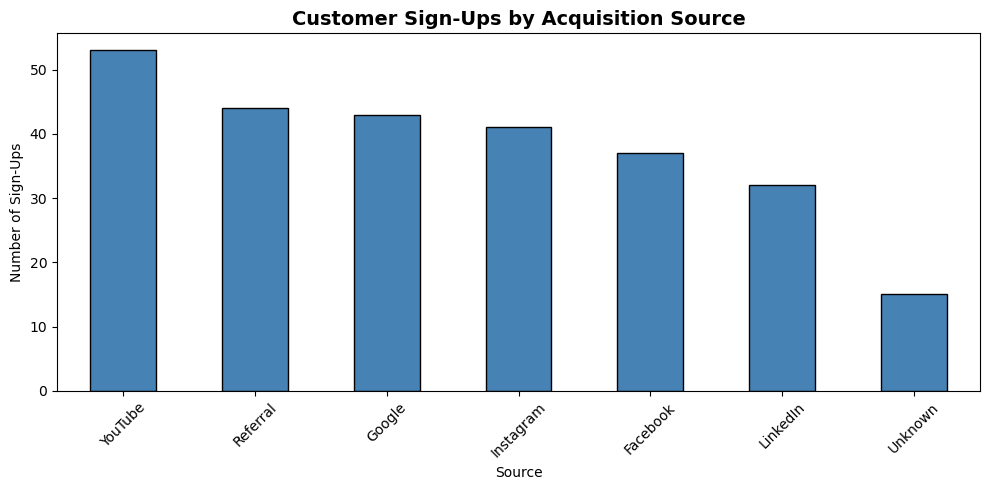

In [43]:
# Chart 1: Sign-ups by acquisition source
plt.figure(figsize=(10, 5))
source_counts = df['source'].value_counts()
source_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Customer Sign-Ups by Acquisition Source', fontsize=14, fontweight='bold')
plt.xlabel('Source')
plt.ylabel('Number of Sign-Ups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

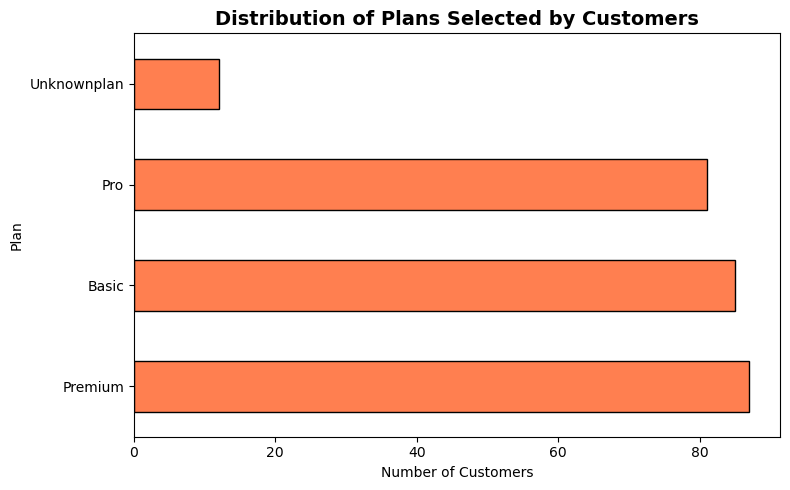

In [44]:
# Chart 2: Plan distribution
plt.figure(figsize=(8, 5))
plan_counts = df['plan_selected'].value_counts()
plan_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Distribution of Plans Selected by Customers', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Plan')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

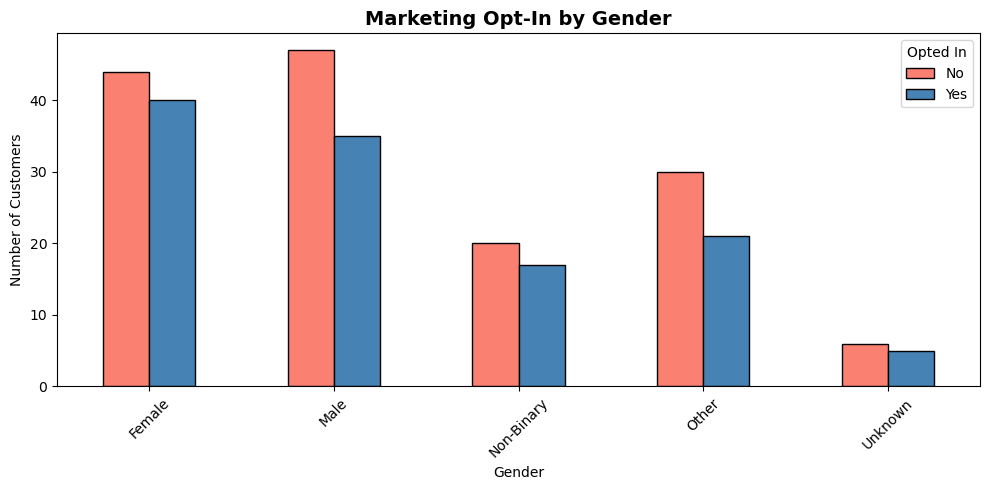

In [45]:
# Chart 3: Marketing opt-in by gender
plt.figure(figsize=(10, 5))
opt_in = df.groupby(['gender', 'marketing_opt_in']).size().unstack(fill_value=0)
opt_in.plot(kind='bar', figsize=(10, 5), color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Marketing Opt-In by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Opted In')
plt.tight_layout()
plt.show()

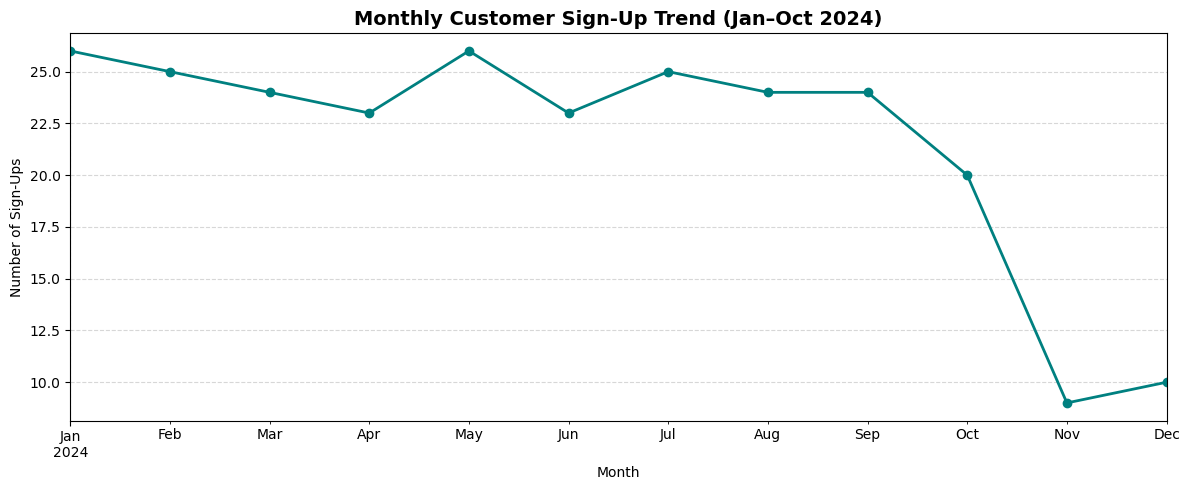

In [46]:
# Chart 4: Sign-ups over time (monthly trend)
plt.figure(figsize=(12, 5))
df_time = df.dropna(subset=['signup_date']).copy()
df_time['signup_date'] = pd.to_datetime(df_time['signup_date'], errors='coerce')
df_time = df_time.dropna(subset=['signup_date'])
monthly = df_time.set_index('signup_date').resample('ME').size()
monthly.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Monthly Customer Sign-Up Trend (Jan–Oct 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Sign-Ups')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Support Ticket Analysis (Stretch Task)
Merging support ticket data to identify customers who raised issues within 2 weeks of signing up.

In [47]:
# Optional stretch task
# Load the support_tickets.csv dataset

tickets = pd.read_csv("support_tickets_.csv")
tickets

,ticket_id,customer_id,ticket_date,issue_type,resolved
0,TKT0000-1,CUST00203,2024-08-17,Billing,Yes
1,TKT0000-2,CUST00203,2024-07-22,Technical Error,Yes
2,TKT0000-3,CUST00203,2024-07-22,Other,Yes
3,TKT0001-1,CUST00266,2024-09-26,Account Setup,Yes
4,TKT0001-2,CUST00266,2024-10-09,Technical Error,No
...,...,...,...,...,...
118,TKT0057-1,CUST00092,2024-02-11,Billing,Yes
119,TKT0058-1,CUST00192,2024-12-02,Billing,Yes
120,TKT0058-2,CUST00192,2024-11-28,Account Setup,Yes
121,TKT0058-3,CUST00192,2024-11-18,Login Issue,Yes


In [48]:
#Join it to customer_signups.csv on customer_id

merged = pd.merge(df, tickets, on='customer_id', how='left')
merged

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender,signup_week,ticket_id,ticket_date,issue_type,resolved
0,CUST00000,Joshua Bryant,Unknown,NaT,Instagram,Unknown,Basic,No,34.0,Female,NaT,NaN,NaN,NaN,NaN
1,CUST00001,Nicole Stewart,nicole1@example.com,2024-02-01,LinkedIn,West,Basic,Yes,29.0,Male,2024-01-29/2024-02-04,NaN,NaN,NaN,NaN
2,CUST00002,Rachel Allen,rachel2@example.com,2024-03-01,Google,North,Premium,Yes,34.0,Non-Binary,2024-02-26/2024-03-03,NaN,NaN,NaN,NaN
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,2024-04-01,YouTube,Unknown,Pro,No,40.0,Male,2024-04-01/2024-04-07,NaN,NaN,NaN,NaN
4,CUST00004,Unknown,matthew4@mailhub.org,2024-05-01,LinkedIn,West,Premium,No,25.0,Other,2024-04-29/2024-05-05,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,CUST00294,Mrs. Jessica Smith,mrs.94@example.com,2024-10-21,Google,South,Pro,Yes,29.0,Other,2024-10-21/2024-10-27,NaN,NaN,NaN,NaN
314,CUST00295,Gary Smith,gary95@example.com,2024-10-22,Google,West,Premium,Yes,40.0,Unknown,2024-10-21/2024-10-27,TKT0027-1,2024-11-01,Other,Yes
315,CUST00296,Anthony Roberts,anthony96@mailhub.org,2024-10-23,Google,Central,Basic,Yes,25.0,Female,2024-10-21/2024-10-27,NaN,NaN,NaN,NaN
316,CUST00298,Justin Mcintyre,justin98@mailhub.org,2024-10-25,YouTube,South,Premium,No,53.0,Male,2024-10-21/2024-10-27,NaN,NaN,NaN,NaN


In [49]:
#Count how many customers contacted support within 2 weeks of sign-up

merged['ticket_date'] = pd.to_datetime(merged['ticket_date'], errors='coerce')
merged['days_to_ticket'] = (merged['ticket_date'] - merged['signup_date']).dt.days
support = merged[merged['days_to_ticket'] <= 14]
support.customer_id.nunique()


41

In [50]:
#Summarise support activity by plan and region (Group by plan and region)

support.groupby(['plan_selected','region']).size()

plan_selected  region 
Basic          Central    2
               East       6
               North      2
               South      9
               Unknown    1
               West       3
Premium        Central    3
               North      3
               South      1
               West       6
Pro            Central    3
               East       6
               North      7
               South      3
               West       2
Unknownplan    North      4
dtype: int64

## Key Insights

**1. YouTube and Instagram are the top acquisition channels**  
YouTube and Instagram together account for the largest share of sign-ups, making them the highest priority channels for the marketing team to invest in.

**2. Premium is the most selected plan**  
The majority of customers opted for Premium, suggesting strong willingness to pay. Basic plan adoption is lowest, the onboarding team should investigate whether Basic users are converting to higher tiers over time.

**3. Marketing opt-in rates are low across all genders**  
Across all gender categories, the majority of customers opted out of marketing communications. This limits the company's ability to re-engage users and warrants a review of the opt-in messaging strategy.

**4. Sign-up volumes were relatively consistent Jan -Oct 2024**  
Monthly trends show no dramatic spikes or drops, suggesting steady organic growth. There is no evidence of a successful seasonal campaign, this is an opportunity to test targeted campaigns.

**5. Data quality issues are a significant risk**  
Region data had a 10% missing rate, emails had 11.3% missing, and age contained text values like "unknown" and "thirty". A standardised data entry process at the point of sign-up would significantly improve reporting reliability.